In [83]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import matplotlib.dates as mdates

# Read sensor files

In [2]:
sensor_name = os.listdir('validation_23_12_21/Data')

In [54]:
sensor_dict = {}

for sensor in sensor_name:
    path = 'validation_23_12_21/Data/{}/'.format(sensor)
    dates = glob.glob(os.path.join(path, '*.csv'))
    date_dict = []
    for date in dates:
        date_dict.append(pd.read_csv(date,skiprows=[1,2,3]))
    sensor_dict[sensor] = pd.concat(date_dict, ignore_index=True)
    print('{} files concatenated'.format(sensor))

BL007-09 files concatenated
BL007-14 files concatenated
BL007-28 files concatenated
BL007-32 files concatenated
BL007-34 files concatenated
BL007-35 files concatenated
BL007-39 files concatenated
BL007-45 files concatenated
BL007-49 files concatenated
BL007-57 files concatenated


In [ ]:
# # create a new directory to save the concatenated files
# os.mkdir('validation_23_12_21/Data_concat')

# # save the concatenated files to the new directory
# for index in sensor_dict:
#     sensor_dict[index].to_csv('validation_23_12_21/Data_concat/{}.csv'.format(index))

# Preprocessing

In [7]:
sensor_dict['BL007-09'].head()

,TIME,TEMP,HUM,BATT,LIGHT,NOISE_A,PRESS,CCS811_VOCS,CCS811_ECO2,PM_1,PM_25,PM_10
0,2023-12-19T09:40:10Z,21.26,49.24,10,0,42.37,101.05,NaN,NaN,NaN,NaN,NaN
1,2023-12-19T09:41:10Z,21.35,49.15,11,0,37.56,101.05,NaN,NaN,NaN,NaN,NaN
2,2023-12-19T09:42:10Z,21.39,49.21,11,0,35.48,101.04,NaN,NaN,NaN,NaN,NaN
3,2023-12-19T09:43:10Z,21.46,49.11,12,0,38.98,101.04,NaN,NaN,NaN,NaN,NaN
4,2023-12-19T09:44:10Z,21.50,49.12,13,0,37.28,101.03,69.0,857.0,0.0,0.0,0.0


In [ ]:
# # select valid time range
# start_timestamp1 = '2023-12-19 19:00:00'
# end_timestamp1 = '2023-12-20 7:00:00'

# start_timestamp2 = '2023-12-20 19:00:00'
# end_timestamp2 = '2023-12-21 7:00:00'

# for index in sensor_dict:
#     df = sensor_dict[index]

#     df['TIME'] = pd.to_datetime(df['TIME'])  
#     df['TIME'] = df['TIME'].dt.floor('min')

#     df_valid = df[((df['TIME'] >= start_timestamp1) & (df['TIME'] <= end_timestamp1))|((df['TIME'] >= start_timestamp2) & (df['TIME'] <= end_timestamp2))]

#     sensor_dict[index] = df_valid

In [55]:
# select valid time range
start_timestamp = '2023-12-19 19:00:00'
end_timestamp = '2023-12-21 7:00:00'

for index in sensor_dict:
    df = sensor_dict[index]

    df['TIME'] = pd.to_datetime(df['TIME'])  
    df['TIME'] = df['TIME'].dt.floor('min')

    df_valid = df[(df['TIME'] >= start_timestamp) & (df['TIME'] <= end_timestamp)]

    sensor_dict[index] = df_valid

# Visualisation

In [56]:
def plot_sensor_data(sensor_dict, column_name, ylabel):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.set_xlabel('Time')
    ax1.set_ylabel(ylabel)
    ax1.tick_params(axis='y')
    ax1.grid(True)

    for sensor_id, df in sensor_dict.items():
        ax1.plot(df['TIME'], df[column_name], label=f'{sensor_id}', linestyle='-', alpha=0.7)

    lines, labels = ax1.get_legend_handles_labels()
    ax1.legend(lines, labels, loc='lower left')
    plt.title(f'Recorded {ylabel} Comparison', fontsize=15)
    plt.show()

## Temperature

In [58]:
temperature_df = pd.concat(
    {
        sensor: df.set_index('TIME')['TEMP']
        for sensor, df in sensor_dict.items()
    },
    axis=1
)

temperature_df['mean'] = temperature_df.mean(axis=1)

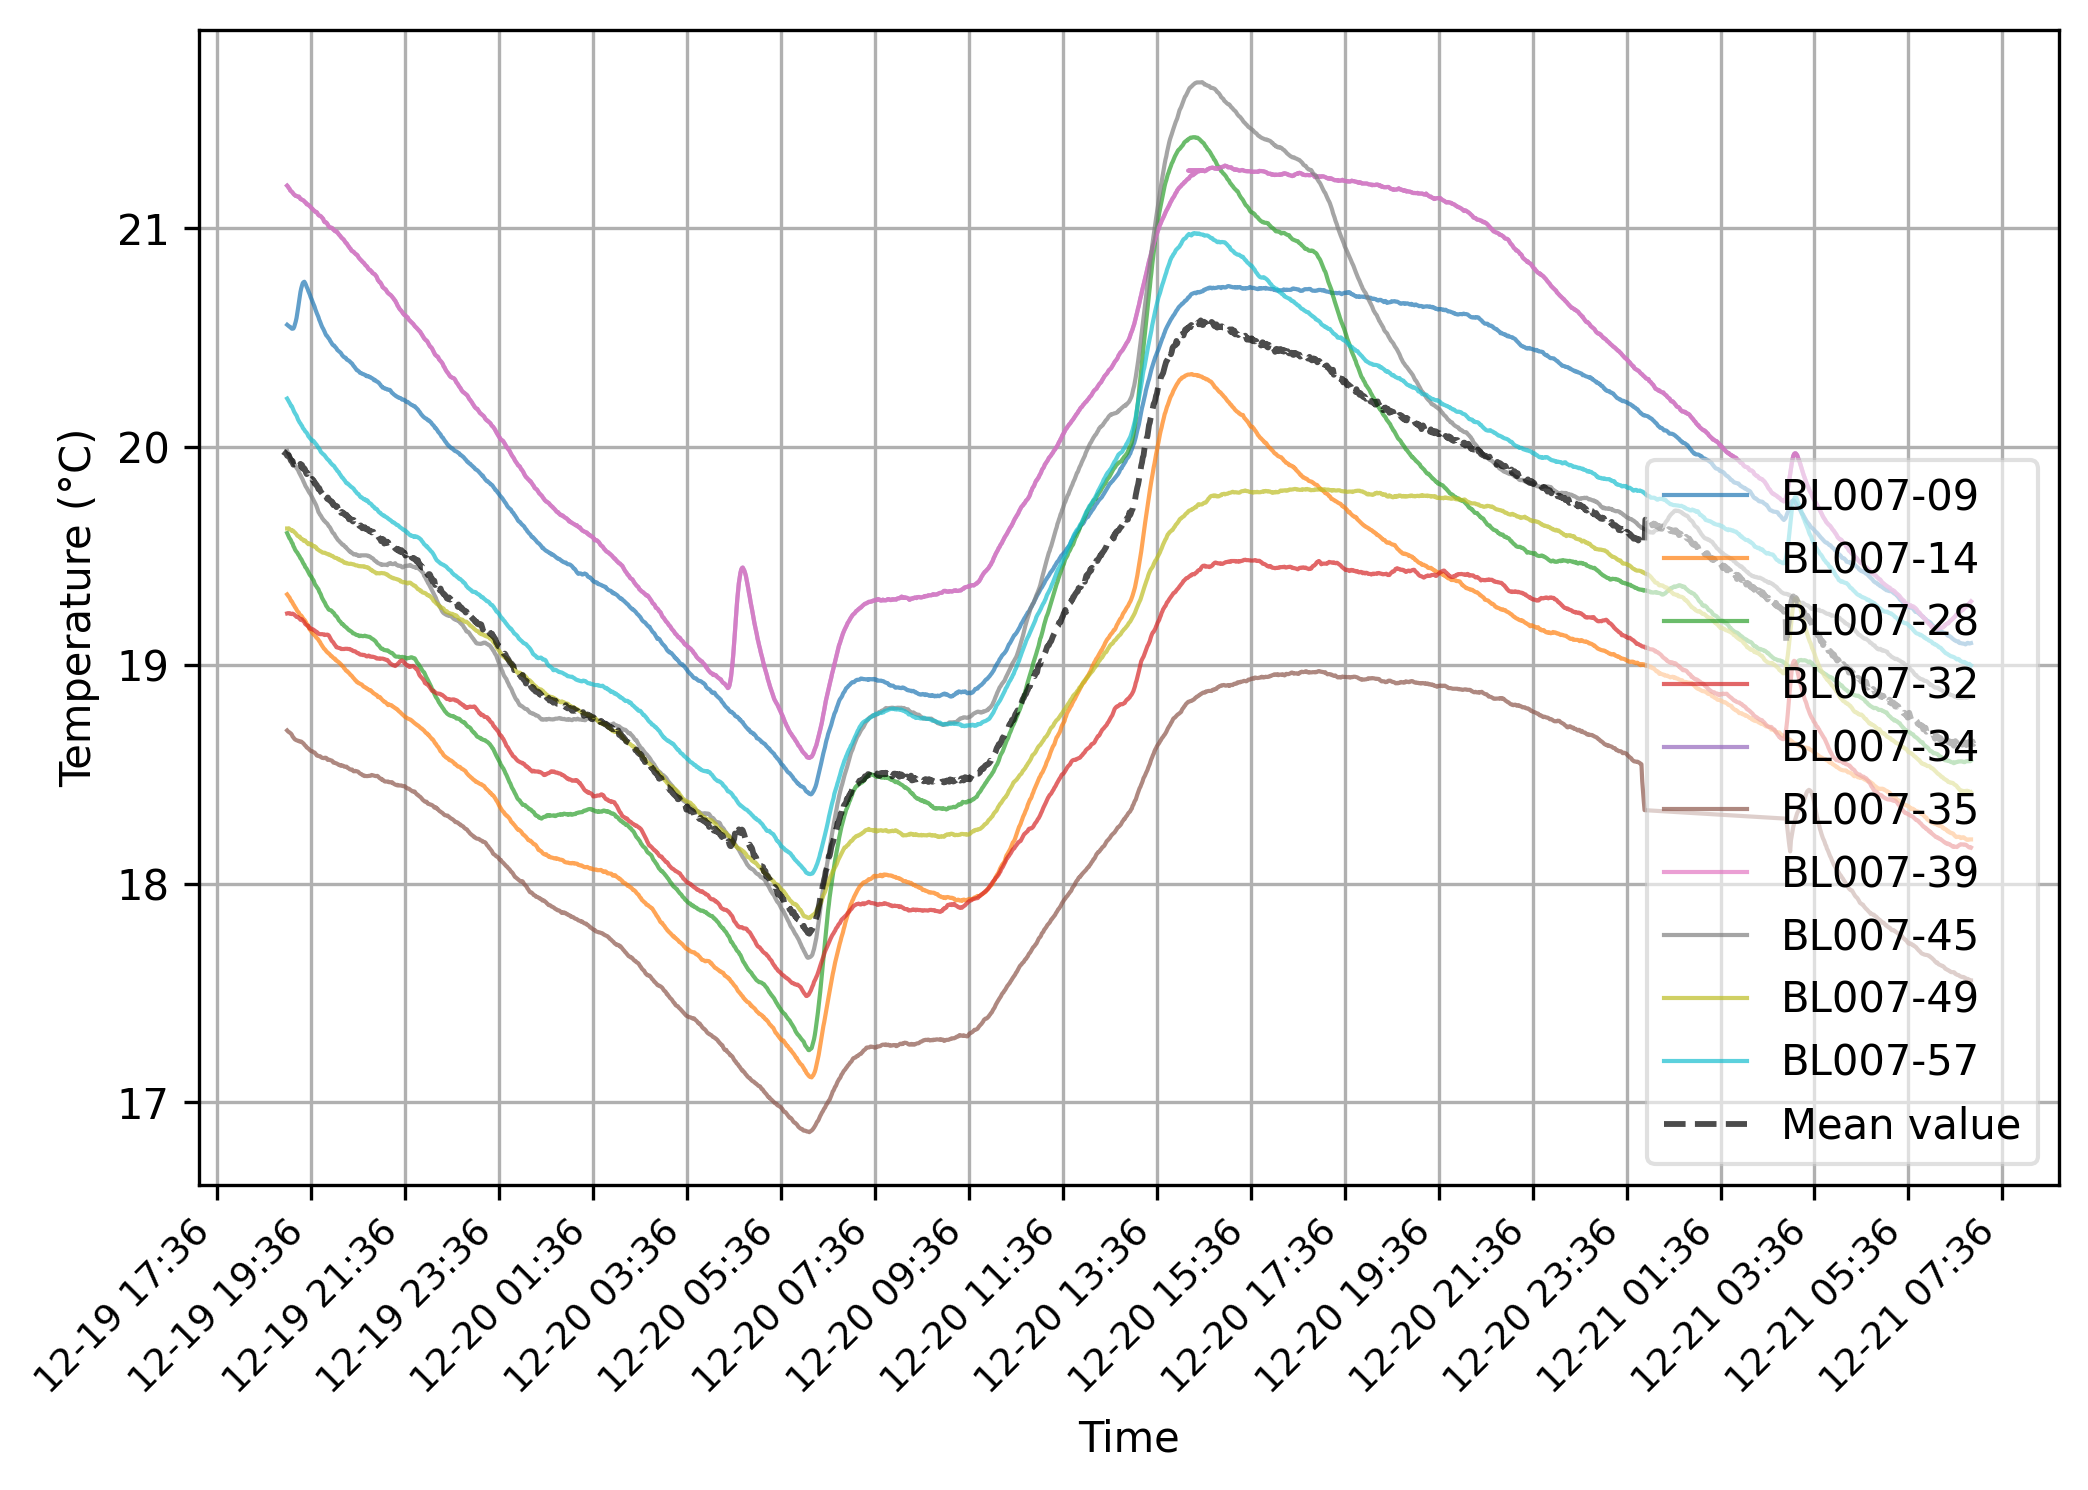

In [93]:
# plot with mean response
fig, ax1 = plt.subplots(figsize=(8, 5),dpi=300)
ax1.grid(True)

# one line for each sensor with rolling mean 
for sensor_id, df in sensor_dict.items():
    df['temp_smooth'] = df['TEMP'].rolling(window=10, center=True).mean()
    ax1.plot(df['TIME'], df['temp_smooth'], label=f'{sensor_id}', linestyle='-', alpha=0.7, linewidth=1)

# mean of all sensors
ax1.plot(temperature_df.index, temperature_df['mean'], c='black', alpha=0.7,linewidth=1.4, linestyle='--', label='Mean value')

lines, labels = ax1.get_legend_handles_labels()
ax1.xaxis.set_major_locator(mdates.RRuleLocator(mdates.rrulewrapper(mdates.HOURLY, interval=2)))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

ax1.legend(lines, labels,loc='lower right',framealpha=0.6)
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (°C)')
plt.xticks(rotation=45,ha='right',fontsize=9)

plt.show()

## Humidity

In [72]:
hum_df = pd.concat(
    {
        sensor: df.set_index('TIME')['HUM']
        for sensor, df in sensor_dict.items()
    },
    axis=1
)

hum_df['mean'] = hum_df.mean(axis=1)

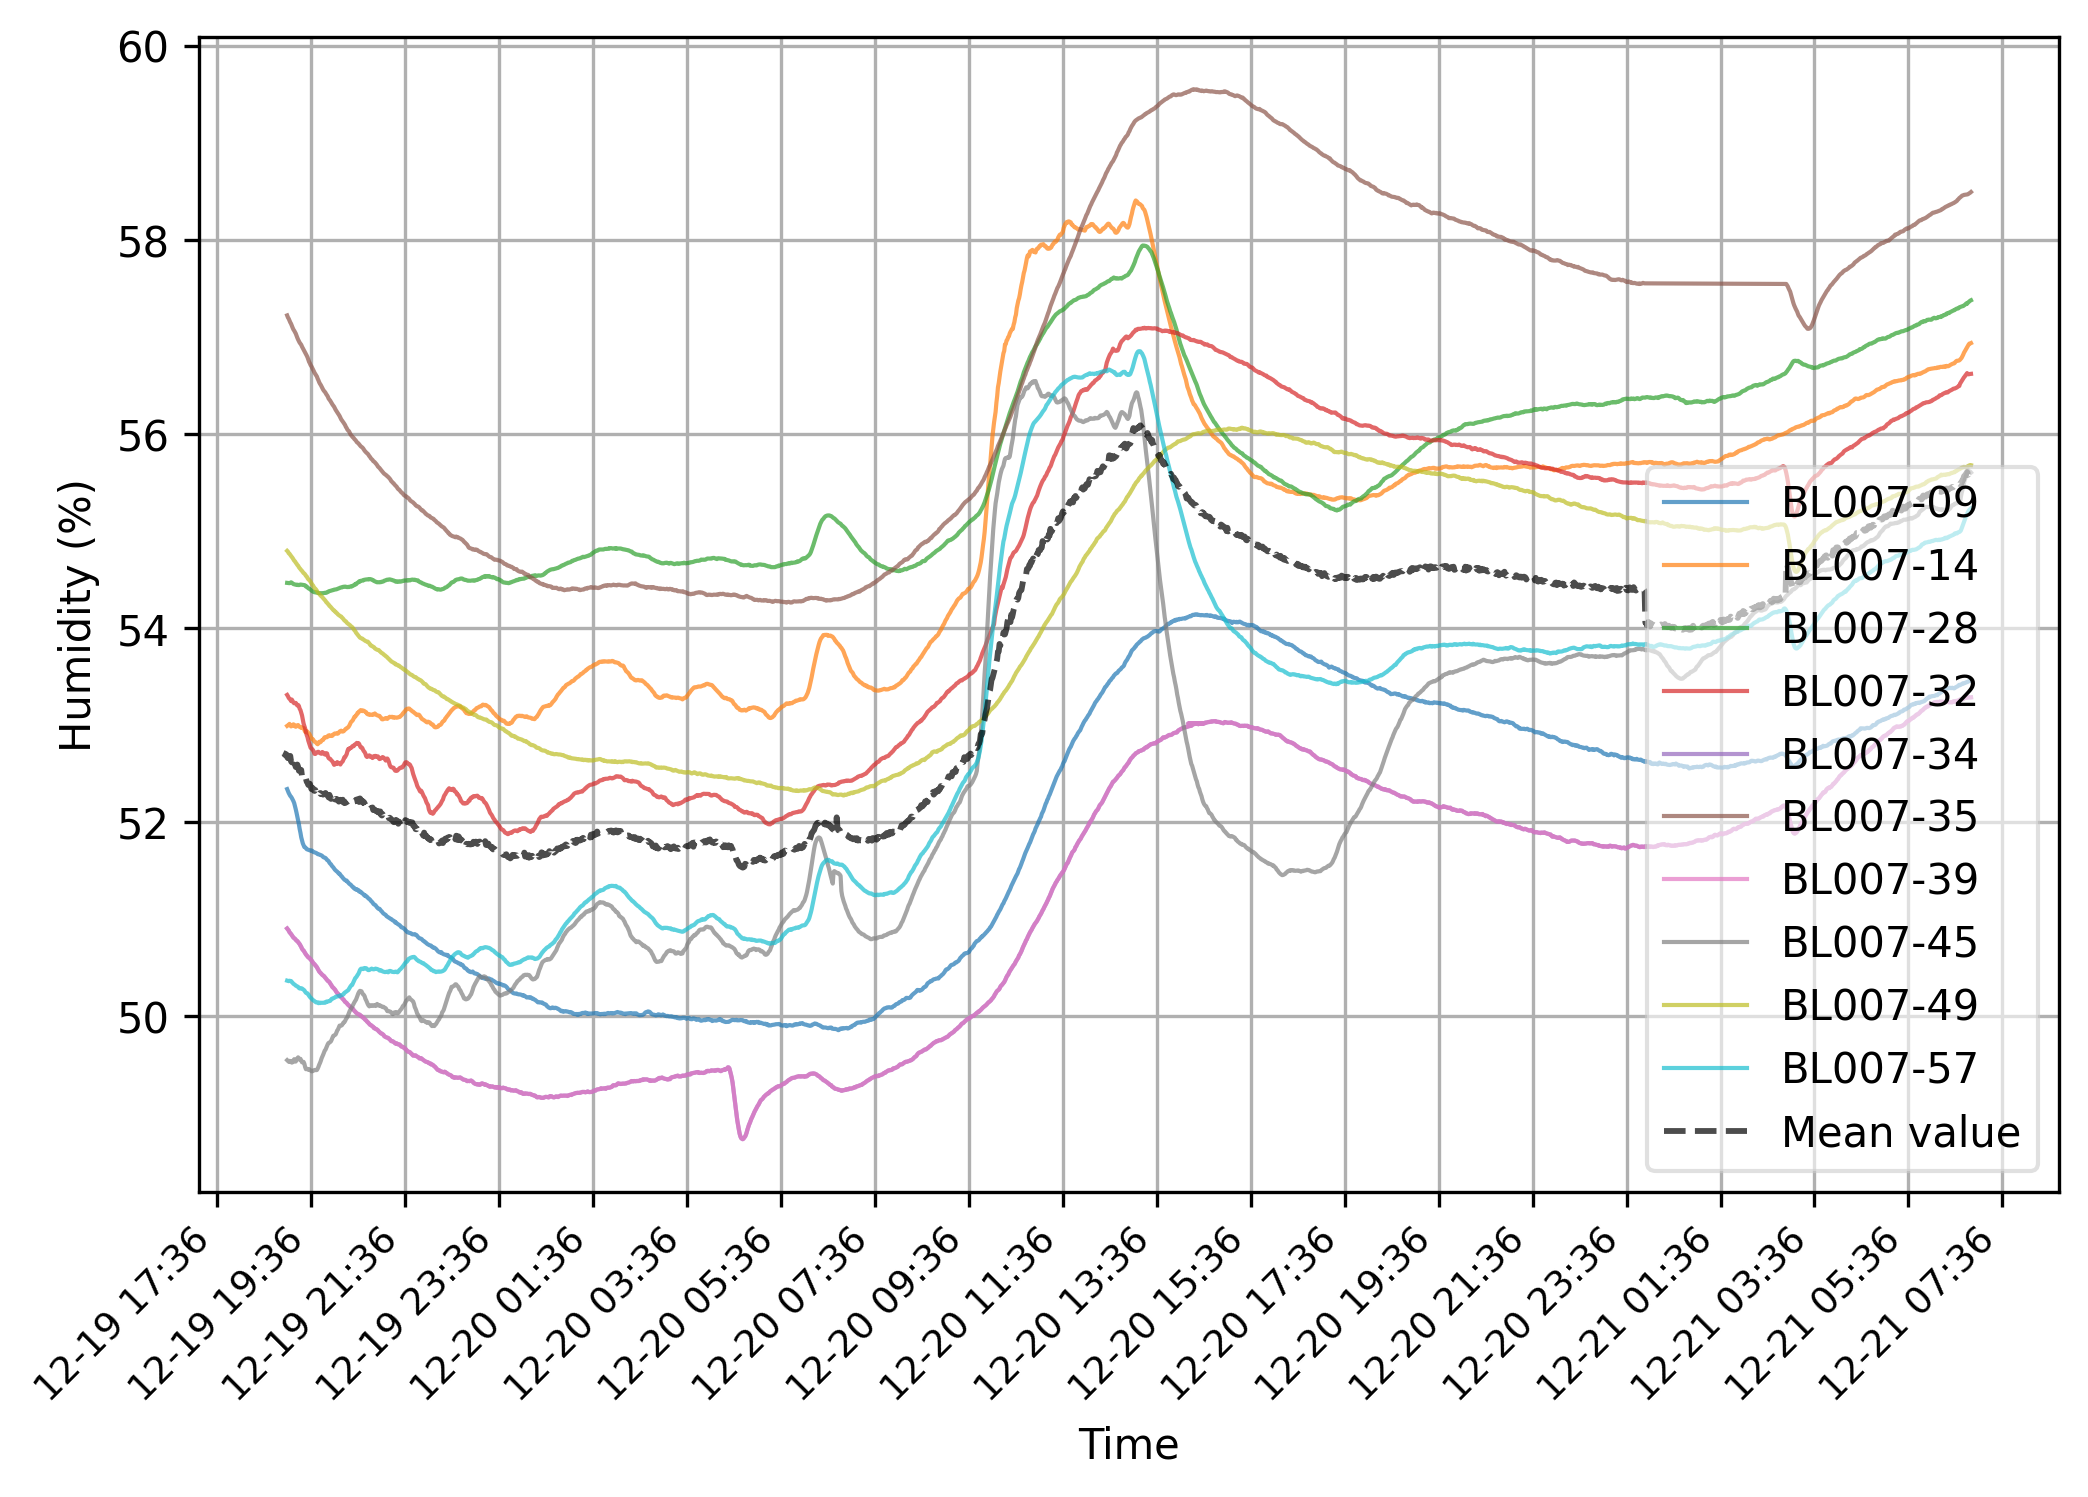

In [89]:
# plot with mean response
fig, ax1 = plt.subplots(figsize=(8, 5),dpi=300)
ax1.grid(True)

# one line for each sensor with rolling mean 
for sensor_id, df in sensor_dict.items():
    df['hum_smooth'] = df['HUM'].rolling(window=10, center=True).mean()
    ax1.plot(df['TIME'], df['hum_smooth'], label=f'{sensor_id}', linestyle='-', alpha=0.7, linewidth=1)

# mean of all sensors
ax1.plot(hum_df.index, hum_df['mean'], c='black', alpha=0.7,linewidth=1.4, linestyle='--', label='Mean value')

lines, labels = ax1.get_legend_handles_labels()
ax1.xaxis.set_major_locator(mdates.RRuleLocator(mdates.rrulewrapper(mdates.HOURLY, interval=2)))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

ax1.legend(lines, labels, loc='lower right',framealpha=0.6)
ax1.set_xlabel('Time')
ax1.set_ylabel('Humidity (%)')
plt.xticks(rotation=45,ha='right',fontsize=9)

plt.show()

## Sound Level 

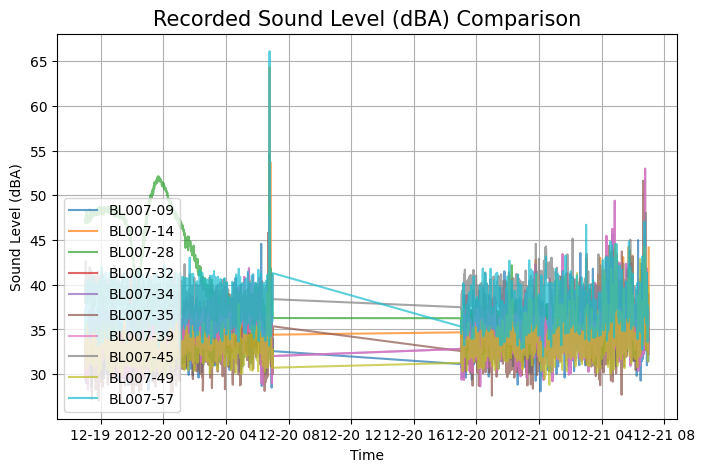

In [17]:
plot_sensor_data(sensor_dict, 'NOISE_A', 'Sound Level (dBA)')

## Air pressure

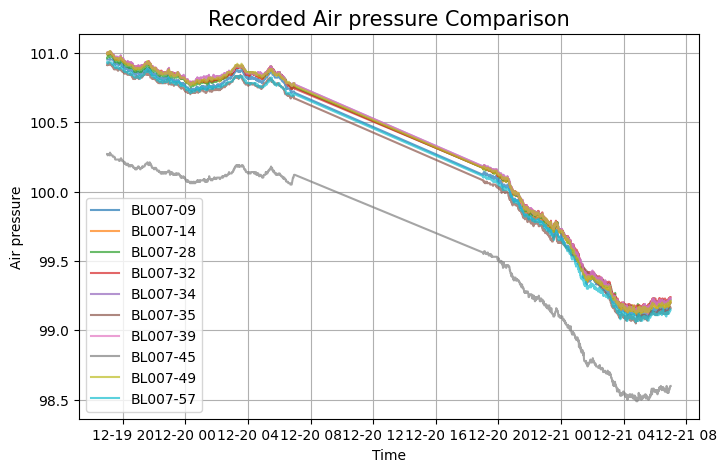

In [ ]:
plot_sensor_data(sensor_dict, 'PRESS', 'Air pressure')

## VOC

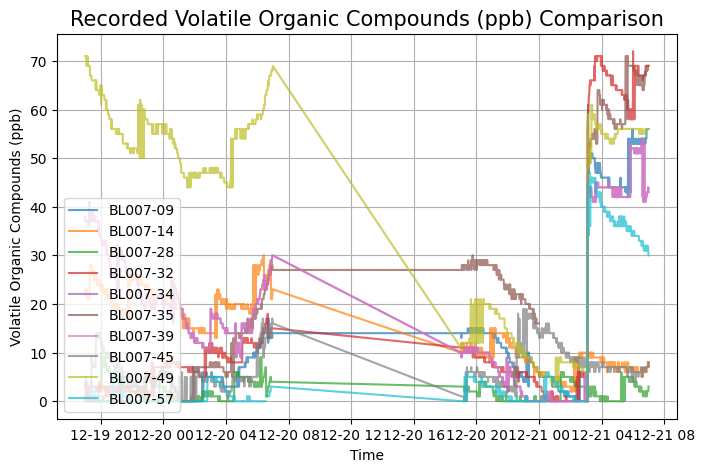

In [21]:
plot_sensor_data(sensor_dict, 'CCS811_VOCS', 'Volatile Organic Compounds (ppb)')

## ECO

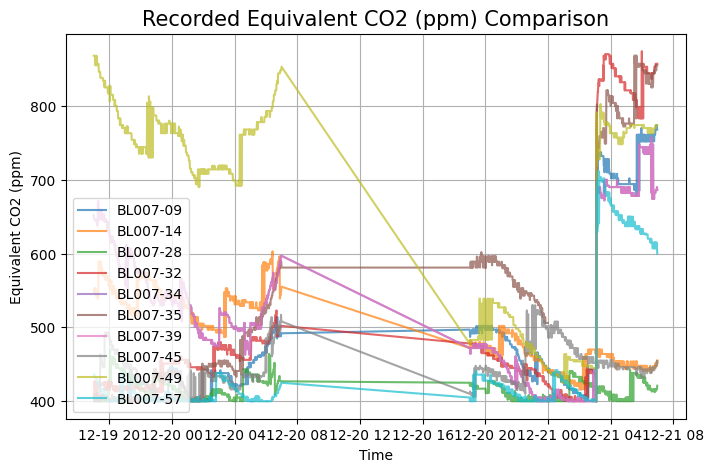

In [22]:
plot_sensor_data(sensor_dict, 'CCS811_ECO2', 'Equivalent CO2 (ppm)')

## PM

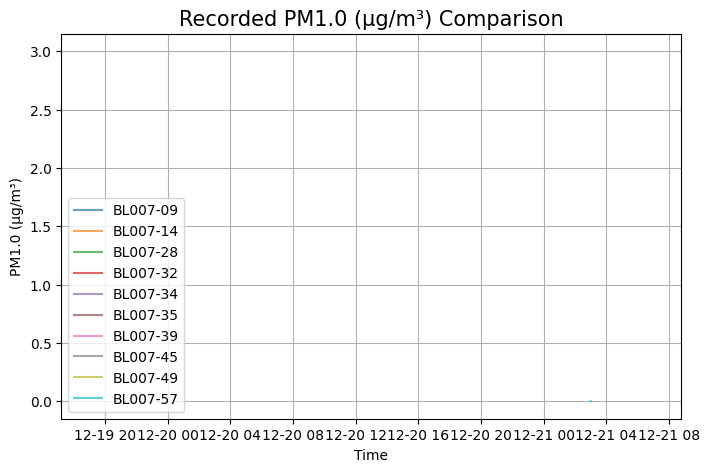

In [24]:
# PM1 
plot_sensor_data(sensor_dict, 'PM_1', 'PM1.0 (µg/m³)')

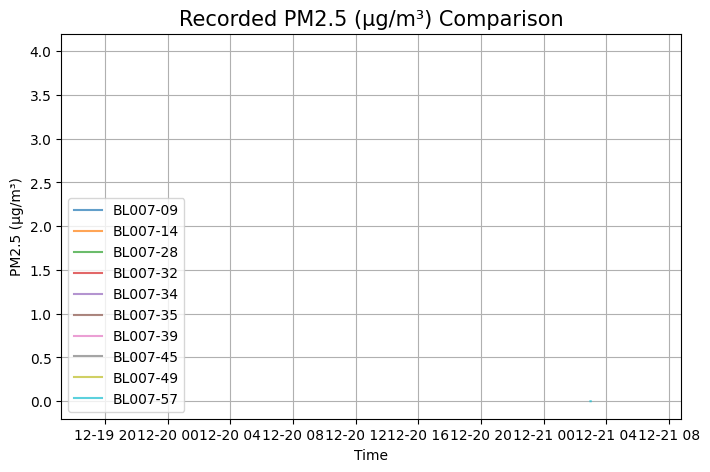

In [25]:
# PM2.5
plot_sensor_data(sensor_dict, 'PM_25', 'PM2.5 (µg/m³)')

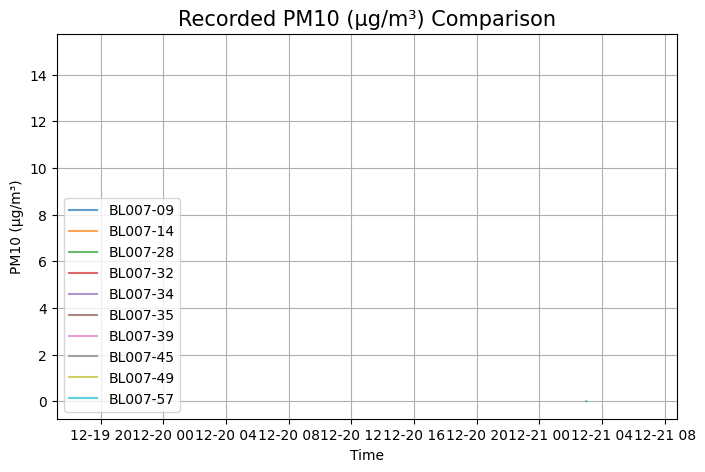

In [26]:
# PM10
plot_sensor_data(sensor_dict, 'PM_10', 'PM10 (µg/m³)')